tf_flowers: This is a widely used dataset containing approximately 3,700 images across five common classes: daisy, dandelion, roses, sunflowers, and tulips. These flower groups(classes) are (i) Daisy, (ii) Dandelion, (iii) Roses, (iv) Sunflowers, and (v) Tulips. This image dataset stored on disk which are in jpg format.

https://www.tensorflow.org/datasets/catalog/tf_flowers


In [1]:
# Import necessary libraries

import matplotlib.pyplot as plt
import numpy as np
import os
import PIL  # Python Imaging Library (PIL)
import tensorflow as tf # TensorFlow is an open-source machine learning framework created by the Google Brain team
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import glob # The glob module finds all the pathnames matching a specified pattern
import pathlib #  Representing filesystem paths with semantics appropriate for different operating systems
import matplotlib
import matplotlib.image as mpimg # to display an image (a NumPy array) in a Matplotlib plot. It interprets a 2D array as a grayscale image by default, using a colormap, and a 3D array as an RGB or RGBA image.
import tarfile
import sys
from collections import Counter
from PIL import Image

In [2]:
# Check versions
print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__) # tf.version.VERSION
print("Keras version:", tf.keras.__version__)
print("Python version",sys.version)
#print("Py Plot version:",plt.__version__)
print("Matplotlib version: " , matplotlib.__version__)

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
Python version 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Matplotlib version:  3.10.0


In [3]:
# Download and explore the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz" # A compressed archive (tar + gzip)
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True) # Download and Unzips / untars the .tgz file
# Returns the path to the extracted folder
data_dir = pathlib.Path(data_dir) / "flower_photos"

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


In [4]:
# Check the directory
print(data_dir)
print([p.name for p in data_dir.iterdir()])


/root/.keras/datasets/flower_photos/flower_photos
['roses', 'daisy', 'dandelion', 'tulips', 'LICENSE.txt', 'sunflowers']


In [5]:
# Count total number of images in the dataset. daisy: 633, dandelion: 898, roses: 641, sunflowers: 699,  tulips: 799
# The glob module in Python is a built-in library used for finding all pathnames that match a specified pattern, following the rules of the Unix shell.
# Daisy
daisy_count = len(list(data_dir.glob('daisy/*.jpg'))) # The glob module finds all the pathnames matching a specified pattern
# Dandelion
dandelion_count = len(list(data_dir.glob('dandelion/*.jpg')))
# Roses
roses_count = len(list(data_dir.glob('roses/*.jpg')))
# Sunflowers
sunflowers_count = len(list(data_dir.glob('sunflowers/*.jpg')))
# Tulips
tulips_count = len(list(data_dir.glob('tulips/*.jpg')))

# Total
# Total flowers. All subfolders, then all jpg files
image_count = len(list(data_dir.glob('*/*.jpg')))

# Display
print("Total number of Daisy: ",daisy_count)
print("Total number of Dandelion: ",dandelion_count)
print("Total number of Roses: ",roses_count)
print("Total number of Sunflowers: ",sunflowers_count)
print("Total number of Tulips: ",tulips_count)
print("Total number of images in the dataset: ",image_count)

Total number of Daisy:  633
Total number of Dandelion:  898
Total number of Roses:  641
Total number of Sunflowers:  699
Total number of Tulips:  799
Total number of images in the dataset:  3670


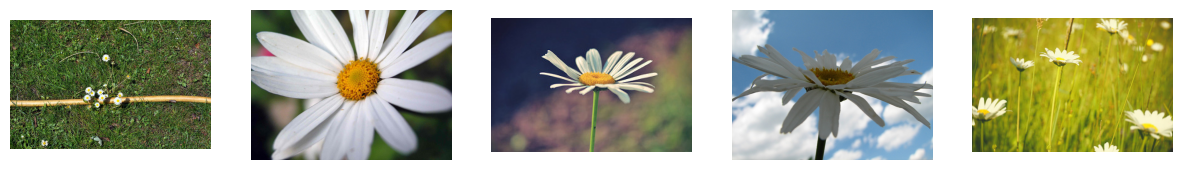

In [6]:
# Let's look into only "daisy" subfolder
daisies = list(data_dir.glob('daisy/*'))
#PIL.Image.open(roses[1])
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(daisies[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

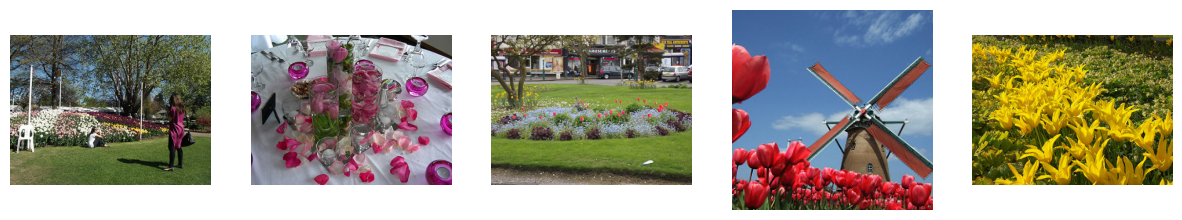

In [7]:
# Display some tulips
tulips = list(data_dir.glob('tulips/*'))
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(tulips[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

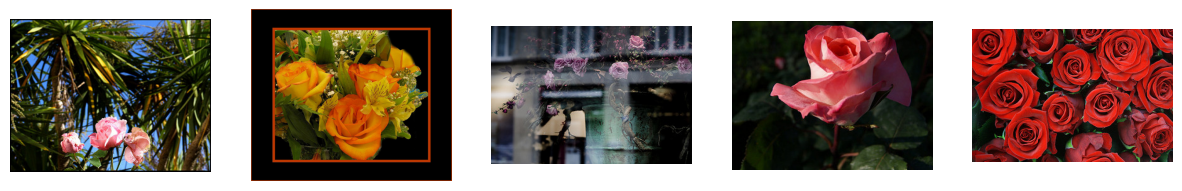

In [8]:
# Display some roses
roses = list(data_dir.glob('roses/*'))
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(roses[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [9]:
# Create a dataset for ML model
# Parameters, Set image size and number of images in each batch
batch_size = 32 # The original paper utilized a batch size of 256 for training, optimized with SGD + momentum.
img_height = 224
img_width = 224

In [10]:
# Data preprocessing
# Generates a tf.data.Dataset from image files in a directory by using tf.keras.preprocessing.image_dataset_from_directory.
# It automatically loads images, assigns labels, resizes them, batches them, and creates a training dataset.
# The tf.keras.preprocessing.image_dataset_from_directory() utility function in TensorFlow is used to generate a tf.data.Dataset object from image files organized in a directory structure.
# Default settings, labess = inferred, we get class names, labes as int32
# Split the image dataset into 8:2. Use 80% of the images for training, and 20% for validation

# Training data set
train_ds = tf.keras.preprocessing.image_dataset_from_directory( # https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123, # Ensure reproducibiliy. Without this Every run may create a different random split.
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [11]:
# Count images per class from train_ds
# Get class names (folder names in order of labels)
class_names = train_ds.class_names
print("Class names:", class_names)

# Initialize counter
counter = Counter()

# Loop through all batches in train_ds
for images, labels in train_ds:
    counter.update(labels.numpy())

# Display counts
total = 0
print("\nNumber of images per class in TRAINING set:")
for i, class_name in enumerate(class_names):
    count = counter[i]
    total += count
    print(f"{class_name:12s}: {count} images")

print("\nTotal training images:", total)

Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of images per class in TRAINING set:
daisy       : 504 images
dandelion   : 722 images
roses       : 521 images
sunflowers  : 547 images
tulips      : 642 images

Total training images: 2936


In [12]:
# validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [13]:
# Count images per class from val_ds
# Get class names (folder names in order of labels)
class_names = val_ds.class_names
print("Class names:", class_names)

# Initialize counter
counter = Counter()

# Loop through all batches in train_ds
for images, labels in val_ds:
    counter.update(labels.numpy())

# Display counts
total = 0
print("\nNumber of images per class in Validation set:")
for i, class_name in enumerate(class_names):
    count = counter[i]
    total += count
    print(f"{class_name:12s}: {count} images")

print("\nTotal validation images:", total)

Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of images per class in Validation set:
daisy       : 129 images
dandelion   : 176 images
roses       : 120 images
sunflowers  : 152 images
tulips      : 157 images

Total validation images: 734


In [14]:
# check the class names in the class_names attribute on these datasets
class_names = train_ds.class_names
print(class_names)
val_class_names = val_ds.class_names
print(val_class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


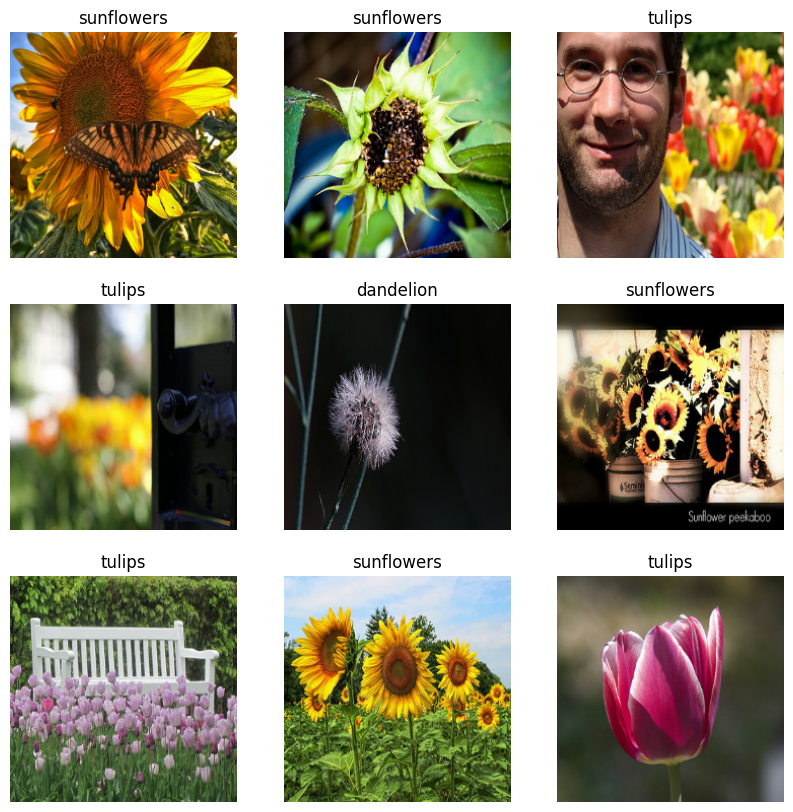

In [15]:
# Visualize the data
# Show 9 images from train dataset with image labels.
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [16]:
# To get information about a numpy array, you can use .shape and .dtype
# The image_batch is a tensor of the shape (32, 180, 180, 3). This is a batch of 32 images of shape 180x180x3 (the last dimension refers to color channels RGB).
# The label_batch is a tensor of the shape (32,), these are corresponding labels to the 32 images.


for image_batch, labels_batch in train_ds:
   print("Shape of image batch:", image_batch.shape)
   print("Data type of image batch:", image_batch.dtype)
   print("Shape of label batch:", labels_batch.shape)
   print("Data type of label batch:", labels_batch.dtype)
   break


Shape of image batch: (32, 224, 224, 3)
Data type of image batch: <dtype: 'float32'>
Shape of label batch: (32,)
Data type of label batch: <dtype: 'int32'>


In [17]:
# Configure the dataset for performance
# This block is not about learning, but about making the CNN training much faster and more efficient by optimizing the data input pipeline. This is a performance optimization pipeline using TensorFlow’s tf.data API.
# Use buffered prefetching to yield data from disk without having I/O become blocking
# Dataset.cache() keeps the images in memory after they're loaded off disk during the first epoch.
# This will ensure the dataset does not become a bottleneck while training your model.
# Dataset.prefetch() overlaps data preprocessing and model execution while training.
# Let TensorFlow automatically decide the best buffer size for prefetching.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [18]:
# Standardize the data
# Preprocess images by normalizing the pixel values to be in the [0, 1] range (originally all values are in the [0, 255] range).
# All images will be rescaled by 1./255 (min-max normalization)
# Without normalization, Gradients can explode or vanish, and Training becomes slower and unstable

# Take one batch (1st) from the training dataset
image_batch, labels_batch = next(iter(train_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,255]`.
print("Before Normalization: ",np.min(first_image), np.max(first_image))

# Rescaling layer (min-max)
normalization_layer = layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# Take one batch (1st) from the normalized dataset
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print("After Normalization: ", np.min(first_image), np.max(first_image))

Before Normalization:  26.161879 255.0
After Normalization:  0.0 0.9992498


In [19]:
# Create the model

num_classes = 5

# VGG-style
# - Use stacks of 3x3 conv layers (multiple convs per block)
# - Then MaxPooling2D to downsample
# - ReLU activations
# - Classifier head (Dense layers)

vgg_model = Sequential([
  # Normalize [0,255] -> [0,1]
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  # Block 1
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Block 2
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Block 3
  layers.Conv2D(256, 3, padding='same', activation='relu'),
  layers.Conv2D(256, 3, padding='same', activation='relu'),
  layers.Conv2D(256, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Block 4
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Block 5
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Classifier head
  layers.Flatten(),

  # VGG originally uses 4096,4096, but that can be huge for Colab + 180x180.
  # This is a lighter but still VGG-like FC head
  layers.Dense(4096, activation='relu'),
  #layers.Dense(512, activation='relu'),
  layers.Dropout(0.5),

  layers.Dense(4096, activation='relu'),
  #layers.Dense(256, activation='relu'),
  layers.Dropout(0.5),

  # Output logits (no softmax here)
  layers.Dense(num_classes)
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
# Model summary
vgg_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,48

 Total params: 134,281,029 (512.24 MB)

 Trainable params: 134,281,029 (512.24 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compile the model
# Using the optimizers as Adam optimizer and losses, SparseCategoricalCrossentropy loss function.
# To view training and validation accuracy for each training epoch, pass the metrics argument.

vgg_model.compile(optimizer='adam', # Defaults lr is 0.001
              # optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [22]:
# Train the model
epochs=10
history = vgg_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  verbose = 2
)

Epoch 1/10
92/92 - 157s - 2s/step - accuracy: 0.2207 - loss: 1.8635 - val_accuracy: 0.2398 - val_loss: 1.6005
Epoch 2/10
92/92 - 48s - 518ms/step - accuracy: 0.2401 - loss: 1.6020 - val_accuracy: 0.2398 - val_loss: 1.6047
Epoch 3/10
92/92 - 48s - 517ms/step - accuracy: 0.2415 - loss: 1.6028 - val_accuracy: 0.2398 - val_loss: 1.6019
Epoch 4/10
92/92 - 48s - 517ms/step - accuracy: 0.2428 - loss: 1.6009 - val_accuracy: 0.2398 - val_loss: 1.6014
Epoch 5/10
92/92 - 48s - 517ms/step - accuracy: 0.2459 - loss: 1.6015 - val_accuracy: 0.2398 - val_loss: 1.6028
Epoch 6/10
92/92 - 48s - 517ms/step - accuracy: 0.2463 - loss: 1.6009 - val_accuracy: 0.2398 - val_loss: 1.6023
Epoch 7/10
92/92 - 48s - 516ms/step - accuracy: 0.2459 - loss: 1.6013 - val_accuracy: 0.2398 - val_loss: 1.6015
Epoch 8/10
92/92 - 48s - 516ms/step - accuracy: 0.2466 - loss: 1.6015 - val_accuracy: 0.2398 - val_loss: 1.6014
Epoch 9/10
92/92 - 47s - 516ms/step - accuracy: 0.2456 - loss: 1.6014 - val_accuracy: 0.2398 - val_loss: 1

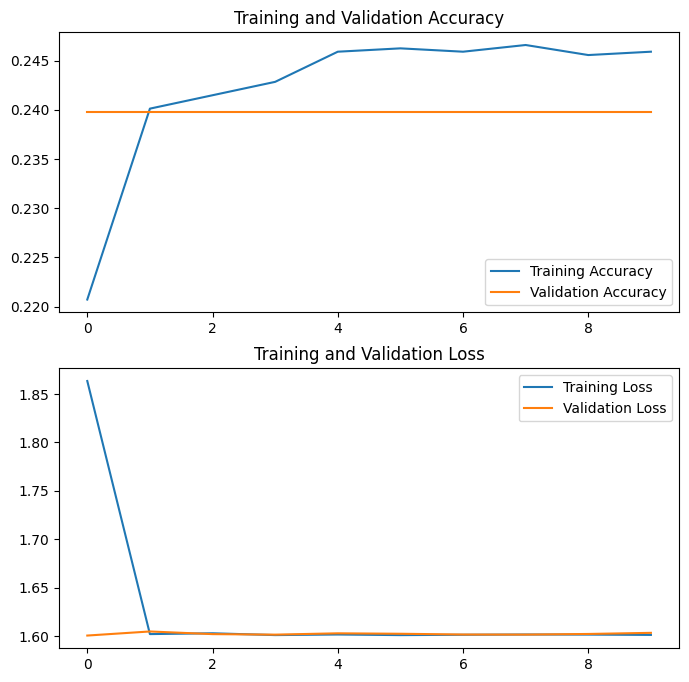

In [23]:
# Visualize training results
# Create plots of loss and accuracy on the training and validation sets

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [24]:
# print maximun accuracy on traning and validation data
# In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 60% in the training process.
# Also, the difference in accuracy between training and validation accuracy is noticeable—a sign of overfitting.
# Overfitting: TL decreasing and VL decreasing at first & then increasing. Low TL but high VL
# Underfitting: High TL and High VL

print("Training Data Accuracy:",max(acc))
print("Validation Data Accuracy",max(val_acc))

Training Data Accuracy: 0.24659401178359985
Validation Data Accuracy 0.23978202044963837


# What can we do to tackle overfitting issues?

In [ ]:
# Use (i)data augmentation and (ii)add Dropout to your model to overcome "overfitting".
# Data augmentation takes the approach of generating additional training data from your existing examples by augmenting them using random transformations that yield believable-looking images.
# Implement data augmentation using the layers from tf.keras.layers.experimental.preprocessing. These can be included inside ML model like other layers, and run on the GPU.

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal",
    input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)


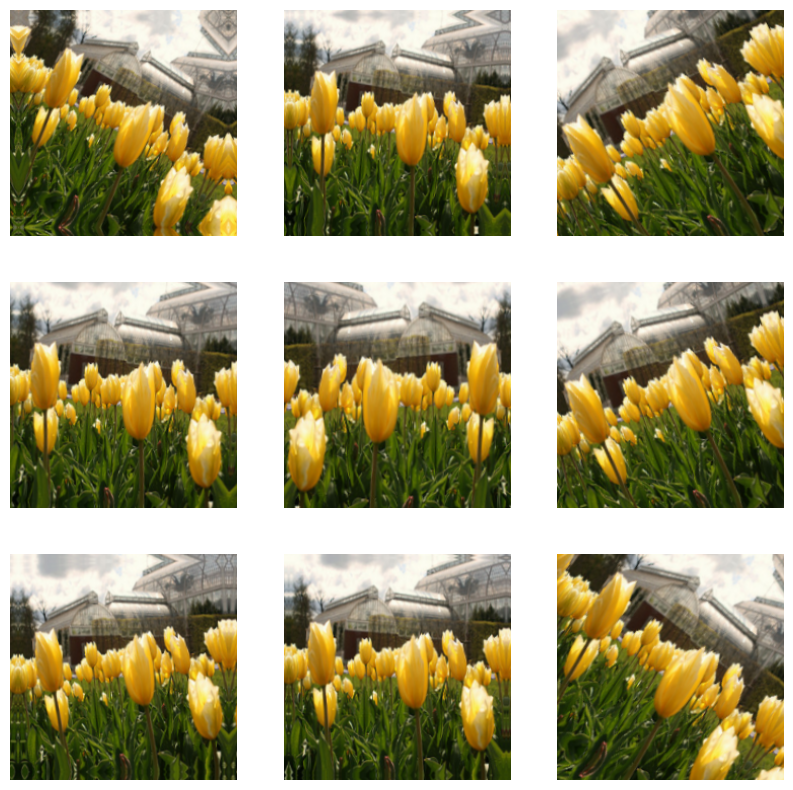

In [ ]:
# Let's visualize what a few augmented examples look like by applying data augmentation to the same image several times

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
# Re design the same model with dropout layer
# Dropout
# When we apply Dropout to a layer it randomly drops out (by setting the activation to zero) a number of output units from the layer during the training process.
# Create a new neural network using layers.Dropout, then train it using augmented images.

num_classes = 5

# VGG-style
# - Use stacks of 3x3 conv layers (multiple convs per block)
# - Then MaxPooling2D to downsample
# - ReLU activations
# - Classifier head (Dense layers)

vgg_model3 = Sequential([
  data_augmentation,
  # Normalize [0,255] -> [0,1]
  #layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  # Block 1
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Block 2
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Block 3
  layers.Conv2D(256, 3, padding='same', activation='relu'),
  layers.Conv2D(256, 3, padding='same', activation='relu'),
  layers.Conv2D(256, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Block 4
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Block 5
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.Conv2D(512, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(pool_size=(2, 2)),

  # Classifier head
  layers.Flatten(),

  # VGG originally uses 4096,4096, but that can be huge for Colab + 180x180.
  # This is a lighter but still VGG-like FC head
  # Yes, the original VGG16 architecture includes dropout layers after the first two fully connected (FC) layers (FC1 and FC2) to reduce overfitting.
  #layers.Dense(4096, activation='relu'),
  layers.Dense(512, activation='relu'),
  layers.Dropout(0.5),

  #layers.Dense(4096, activation='relu'),
  layers.Dense(256, activation='relu'),
  layers.Dropout(0.5),

  # Output logits (no softmax here)
  layers.Dense(num_classes)
])



In [ ]:
# Model summary

vgg_model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,28

 Total params: 27,692,869 (105.64 MB)

 Trainable params: 27,692,869 (105.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train the model

vgg_model3.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# Train the model
epochs = 10
history3 = vgg_model3.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  verbose = 1
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 571ms/step - accuracy: 0.2119 - loss: 28.7691 - val_accuracy: 0.2875 - val_loss: 1.5963
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 435ms/step - accuracy: 0.2517 - loss: 1.6131 - val_accuracy: 0.3351 - val_loss: 1.5152
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 436ms/step - accuracy: 0.2538 - loss: 1.6078 - val_accuracy: 0.2398 - val_loss: 1.5985
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 434ms/step - accuracy: 0.2553 - loss: 1.5982 - val_accuracy: 0.2398 - val_loss: 1.6019
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 424ms/step - accuracy: 0.2488 - loss: 1.5957 - val_accuracy: 0.2398 - val_loss: 1.6015
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 422ms/step - accuracy: 0.2443 - loss: 1.5998 - val_accuracy: 0.2398 - val_loss: 1.6017
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 421ms/step - accuracy: 0.2337 - loss: 1.6016 - val_accuracy: 0.2398 - val_loss: 1.6020
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 421ms/step - accuracy: 0.2331 - loss: 1.6002 - val_acc

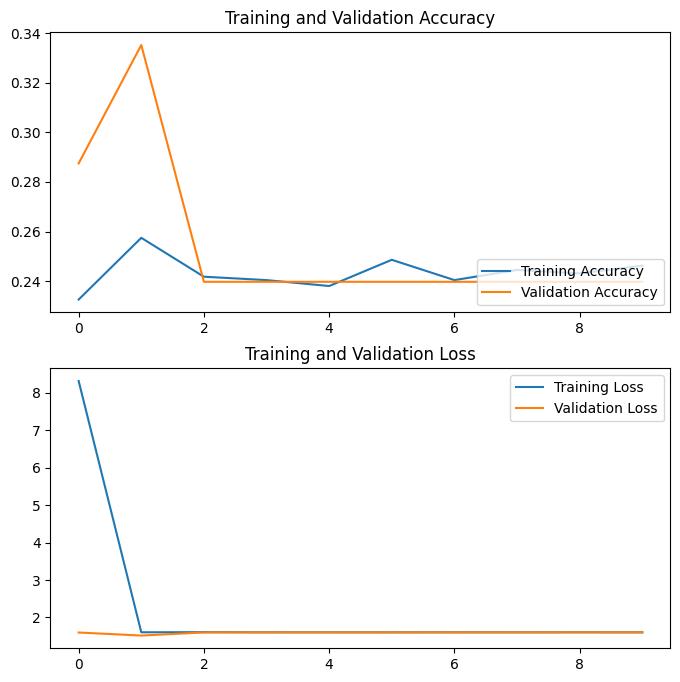

In [ ]:
# After applying data augmentation and Dropout, there is less overfitting than before, and training and validation accuracy are closer aligned

acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']

loss = history3.history['loss']
val_loss = history3.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Diplay basic statistics
import statistics as st
print("The maximum training Data Accuracy:",max(acc))
print("The maximum validation Data Accuracy",max(val_acc))
print("Average training Data Accuracy:",st.mean(acc))
print("Average validation Data Accuracy",st.mean(val_acc))

The maximum training Data Accuracy: 0.25749319791793823
The maximum validation Data Accuracy 0.3351498544216156
Average training Data Accuracy: 0.24335831105709077
Average validation Data Accuracy 0.2540871948003769


In [ ]:
# Predict on new data
# Note: Data augmentation and Dropout layers are inactive at inference time.

sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = keras.preprocessing.image.load_img(
    sunflower_path, target_size=(img_height, img_width))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch (of zero)

predictions = model3.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

117948/117948 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
This image most likely belongs to sunflowers with a 99.46 percent confidence.
